In [23]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.services.indicators import avwap_func_nb, atr_trailing_nb

import numba
@numba.njit
def shift_numba(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    if num > 0:
        result[:num] = fill_value
        result[num:] = arr[:-num]
    elif num < 0:
        result[num:] = fill_value
        result[:num] = arr[-num:]
    else:
        result[:] = arr
    return result


In [ ]:
## Load datasource from deltalake and save it to local h5 file
# REMOTE_HOST = "http://192.168.1.30:9000"
REMOTE_HOST = "https://minio.phuchuynh.site"
site
from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
df


Loading stock data from local HDF5 file: stocks_data_latest.h5


close                                                        \
symbol           AAA        ABB        ACB        ACV       ADS        AGG   
date                                                                         
2016-01-29  6.892738   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-01  7.196829   8.201591   3.616231  20.629999  3.940815  15.284813   
2016-02-02  7.298193   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-03  7.196829   8.201591   3.635365  20.629999  3.940815  15.284813   
2016-02-04  7.247511   8.201591   3.635365  20.629999  3.940815  15.284813   
...              ...        ...        ...        ...       ...        ...   
2026-01-21  7.970000  14.300000  24.850000  59.799999  8.240000  14.650000   
2026-01-22  8.110000  14.100000  24.850000  60.400002  8.220000  15.150000   
2026-01-23  8.000000  14.200000  25.049999  59.400002  8.300000  14.700000   
2026-01-26  7.810000  13.900000  24.799999  53.400002  8.220000  14.650000   
2026-01-27  7.800000  13.800000  24.700001  51.200001  8.150000  14.500000   

                                                       ...        volume  \
symbol            AGR        ANV        APH       ASM  ...       VNINDEX   
date                                                   ...                 
2016-01-29   2.744280  17.299999  30.166281  8.001494  ...  9.877289e+07   
2016-02-01   2.744280  17.299999  30.166281  7.954974  ...  9.151639e+07   
2016-02-02   2.561327  17.299999  30.166281  7.861933  ...  8.205790e+07   
2016-02-03   2.652804  17.299999  30.166281  7.861933  ...  7.248801e+07   
2016-02-04   2.561327  17.299999  30.166281  7.954974  ...  5.899160e+07   
...               ...        ...        ...       ...  ...           ...   
2026-01-21  16.150000  26.200001   6.440000  6.410000  ...  1.186887e+09   
2026-01-22  16.350000  26.799999   6.470000  6.440000  ...  9.453971e+08   
2026-01-23  16.250000  26.900000   6.390000  6.380000  ...  8.795579e+08   
2026-01-26  15.900000  27.150000   6.300000  6.270000  ...  1.102434e+09   
2026-01-27  15.950000  26.700001   6.300000  6.150000  ...  7.826771e+08   

                                                                    \
symbol             VNM        VOS         VPB       VPG        VPI   
date                                                                 
2016-01-29    178270.0    11700.0  58299312.0    5000.0     5000.0   
2016-02-01    865310.0     7000.0  58299312.0    5000.0     5000.0   
2016-02-02    251520.0     1730.0  58299312.0    5000.0     5000.0   
2016-02-03    269870.0     2030.0  58299312.0    5000.0     5000.0   
2016-02-04    257320.0    70230.0  58299312.0    5000.0     5000.0   
...                ...        ...         ...       ...        ...   
2026-01-21  11234100.0  1343000.0  34082700.0  205800.0  2018800.0   
2026-01-22   8055200.0  4522500.0  19795300.0   97700.0  1522200.0   
2026-01-23  16050400.0  3865500.0  31092900.0  134200.0  1268600.0   
2026-01-26   8864800.0  2987900.0  32470600.0   74600.0  1128700.0   
2026-01-27   8357800.0  1986600.0   7349400.0  136600.0  1404300.0   

                                                          
symbol             VRE         VSC        VTP        YEG  
date                                                      
2016-01-29       800.0    107040.0      300.0     6100.0  
2016-02-01       800.0    702150.0      300.0     6100.0  
2016-02-02       800.0    251650.0      300.0     6100.0  
2016-02-03       800.0    121570.0      300.0     6100.0  
2016-02-04       800.0    202610.0      300.0     6100.0  
...                ...         ...        ...        ...  
2026-01-21   6966700.0  16271000.0  1228500.0  4410300.0  
2026-01-22   7252900.0   8567000.0  1317800.0  2965300.0  
2026-01-23   7919100.0   9390200.0  1410100.0  2026800.0  
2026-01-26   6004100.0  12339600.0  1131100.0  1618300.0  
2026-01-27  10746100.0   5417100.0   815700.0   727900.0  

[2498 rows x 990 columns]

# Strategy

In [ ]:
# Count consecutive bar ttm < 0 > 0 (2D)
@nb.njit
def count_consecutive_neg_2d(arr):
    n, m = arr.shape
    out = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


## Williams Vix Fix Formula
def williams_vix_fix_signal(close, high, low, period=22, mult=2.0,
    bbl: int = 20,
    lb: int = 50,
    ph: float = 0.85, # percentile high
    ltLB: int = 40,
    mtLB: int = 14,
    strength_str: int = 2):
    

    MAX = vbt.IndicatorFactory.from_talib("MAX")
    SMA = vbt.IndicatorFactory.from_talib("SMA")
    STDDEV = vbt.IndicatorFactory.from_talib("STDDEV")
    # 1) WVF
    highest_close = MAX.run(close, timeperiod=period).real
    wvf = ((highest_close - low) / highest_close) * 100.0

    # 2) Bands
    midLine = SMA.run(wvf, timeperiod=bbl).real
    sDev = STDDEV.run(wvf, timeperiod=bbl).real * mult
    upperBand = midLine + sDev
    rangeHigh = MAX.run(wvf, timeperiod=lb).real * ph

    # # 3) Conditions
    low_np = low.to_numpy()
    close_np = close.to_numpy()
    high_np = high.to_numpy()
    wvf_np = wvf.to_numpy()
    upperBand_np = upperBand.to_numpy()
    rangeHigh_np = rangeHigh.to_numpy()

    upRange = (low_np > shift_numba(low_np, 1)) & (close_np > shift_numba(high_np, 1))

    filtered = (
        ((wvf_np >= shift_numba(upperBand_np, 1)) | (wvf_np >= shift_numba(rangeHigh_np, 1)))
        & (wvf_np < upperBand_np)
        & (wvf_np < rangeHigh_np)
    )

    cond_FE = (
        upRange
        & (close_np > shift_numba(close_np, strength_str))
        & ((close_np < shift_numba(close_np, ltLB)) | (close_np < shift_numba(close_np, mtLB)))
        & filtered
    )

    cond = pd.DataFrame(cond_FE, index=close.index, columns=close.columns)
    return cond
     

def strategy_william_vix(close, high, low, args):
    ## BB from TA-lib
    # bb_indicator = vbt.IndicatorFactory.from_talib('BBANDS')
    # bb = bb_indicator.run(close, timeperiod=args['bb_period'], nbdevup=args['bb_multiplier'], nbdevdn=args['bb_multiplier'], matype=args['matype'])

    # ## Keltner Channel from TA-lib
    # atr_indicator = vbt.IndicatorFactory.from_talib('ATR')
    # atr = atr_indicator.run(high, low, close, timeperiod=args['kc_atr_period'])
    # ema_indicator = vbt.IndicatorFactory.from_talib('EMA')
    # ema = ema_indicator.run(close, timeperiod=args['kc_period'])
    # kc = ema.real + args['kc_multiplier'] * atr.real

    # ## Squeeze detection
    # squeeze_diff = bb.upperband.vbt - kc ## squeeze_on if diff < 0, fired if diff > 0

    # # Oscillator
    # hhv_indicator = vbt.IndicatorFactory.from_talib('MAX')
    # llv_indicator = vbt.IndicatorFactory.from_talib('MIN')

    # sma_indicator = vbt.IndicatorFactory.from_talib('SMA')
    # sma = sma_indicator.run(close, timeperiod=args['donichan_period']).real

    # hh = hhv_indicator.run(high, timeperiod=args['donichan_period']).real
    # ll = llv_indicator.run(low, timeperiod=args['donichan_period']).real
    # mid = (hh + ll) / 2
    # histogram = close - ( (mid + sma) / 2 )

    # ## smooth histogram
    # linear_reg_indicator = vbt.IndicatorFactory.from_talib('LINEARREG')
    # ttms = linear_reg_indicator.run(histogram, timeperiod=args['osc_smoothing_period']).real

    # squeeze_diff_np = squeeze_diff.to_numpy()
    # ttms_np = ttms.to_numpy()
    # consecutive_negative_bar_ttm_np = count_consecutive_neg_2d(ttms_np)

    williams_vix_fix_signal_np = williams_vix_fix_signal(close, high, low, 
        period=args['william_vix_period'], mult=args['bb_multiplier'], bbl=args['bb_period'], 
        lb=50, ph=0.85, ltLB=40, mtLB=14, strength_str=3)
    
    # ## Entry 1: Breakout from squeeze
    # entry_1 = (shift_numba(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0) & (ttms > 0)
    # ## Entry 2: 
    # entry_2 = (shift_numba(squeeze_diff_np, 1) < 0) & (squeeze_diff_np > 0) & (consecutive_negative_bar_ttm_np > 7)
    # buy_signal = entry_1 | entry_2 | williams_vix_fix_signal_np
    buy_signal = williams_vix_fix_signal_np
    print(buy_signal)

    atr_trailing_real = vbt.IndicatorFactory.from_talib("ATR").run(high, low, close, timeperiod=10).real
    atr_trailing_indicator = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing']
    ).from_apply_func(atr_trailing_nb)
    atr_sl = atr_trailing_indicator.run(close, atr_trailing_real, atr_multiplier=1.9)
    exit1 = close.vbt.crossed_below(atr_sl.atr_trailing)

    ## Max low stoploss
    lowest_low = vbt.IndicatorFactory.from_talib("MIN").run(low, timeperiod=args['donichan_period']).real
    exit2 = close < shift_numba(lowest_low.to_numpy(), 1)
    sell_signal = exit1

    pf = vbt.Portfolio.from_signals(
        close=close, 
        entries=buy_signal, 
        exits=sell_signal, 
        freq='1d', 
        group_by=['symbol'],
        sl_stop=0.1,  # 10% hard stop loss
    )
    return pf

## Breakout strategy
close = df.close.copy().round(2)
high = df.high.copy().round(2)
low = df.low.copy().round(2)
# args = {'bb_period': 10, 'bb_multiplier': 1.8, 'kc_period': 14, 'kc_atr_period': 10, 'kc_multiplier': 1.1, 'donichan_period': 10, 'osc_smoothing_period': 10}
args = {'bb_period': 10, 'bb_multiplier': 1.2, 'kc_period': 13, 'kc_atr_period': 10, 'kc_multiplier': 1.0, 
    'donichan_period': 10, 'osc_smoothing_period': 5, 'matype': 3, 'william_vix_period': 20}
pf = strategy_william_vix(close, high, low, args)

## set bet params
best_params = {'bb_period': 10, 'bb_multiplier': 1.3, 'kc_period': 10, 'kc_atr_period': 12, 'kc_multiplier': 1.0, 'donichan_period': 13, 'osc_smoothing_period': 6, 'william_vix_period': 25, 'matype': 3}
pf.stats()


symbol        AAA    ABB    ACB    ACV    ADS    AGG    AGR    ANV    APH  \
date                                                                        
2016-01-29  False  False  False  False  False  False  False  False  False   
2016-02-01  False  False  False  False  False  False  False  False  False   
2016-02-02  False  False  False  False  False  False  False  False  False   
2016-02-03  False  False  False  False  False  False  False  False  False   
2016-02-04  False  False  False  False  False  False  False  False  False   
...           ...    ...    ...    ...    ...    ...    ...    ...    ...   
2026-01-21  False  False  False  False  False  False  False  False  False   
2026-01-22  False  False  False  False  False  False  False  False  False   
2026-01-23  False  False  False  False  False  False  False  False  False   
2026-01-26  False  False  False  False  False  False  False  False  False   
2026-01-27  False  False  False  False  False  False  False  False  False   

Start                                2016-01-29 00:00:00
End                                  2026-01-27 00:00:00
Period                                2498 days 00:00:00
Start Value                                        100.0
End Value                                     103.032136
Total Return [%]                                3.032136
Benchmark Return [%]                          294.988276
Max Gross Exposure [%]                         62.121212
Total Fees Paid                                      0.0
Max Drawdown [%]                                9.625333
Max Drawdown Duration                 1083 days 08:00:00
Total Trades                                    0.944444
Total Closed Trades                             0.939394
Total Open Trades                               0.005051
Open Trade PnL                                       0.0
Win Rate [%]                                   46.097561
Best Trade [%]                                  6.602562
Worst Trade [%]                

In [175]:
# =============================================================================
# Optuna Optimization for Bollinger Squeeze with DeMarker Strategy
# =============================================================================
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

## Breakout strategy
close = df.close.copy().round(2)
high = df.high.copy().round(2)
low = df.low.copy().round(2)

def objective(trial):
    """
    Optuna objective function to maximize mean Sharpe ratio.
    """
    # Suggest parameters
    bb_period = trial.suggest_int('bb_period', 10, 25)
    bb_multiplier = trial.suggest_float('bb_multiplier', 1, 2.5, step=0.1)
    kc_period = trial.suggest_int('kc_period', 10, 25)
    kc_atr_period = trial.suggest_int('kc_atr_period', 10, 25)
    kc_multiplier = trial.suggest_float('kc_multiplier', 1, 2.5, step=0.1)
    donichan_period = trial.suggest_int('donichan_period', 10, 30)
    osc_smoothing_period = trial.suggest_int('osc_smoothing_period', 5, 20)
    william_vix_period = trial.suggest_int('william_vix_period', 10, 30)
    matype = trial.suggest_int('matype', 0, 3)
    
    try:
        args = {'bb_period': bb_period, 'bb_multiplier': bb_multiplier, 'kc_period': kc_period, 'kc_atr_period': kc_atr_period, 'kc_multiplier': kc_multiplier, 'donichan_period': donichan_period, 
            'osc_smoothing_period': osc_smoothing_period, 'matype': matype, 'william_vix_period': william_vix_period}
        pf = strategy_breakout_ttm(close, high, low, args)
        
        # Calculate Sharpe ratios
        sharpe_ratios = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(sharpe_ratios) == 0:
            return -100.0  # Penalty for no valid trades
        
        # Objective: maximize mean Sharpe ratio
        mean_sharpe = sharpe_ratios.mean()
        
        # Additional penalty if too few symbols have positive Sharpe
        positive_sharpe_pct = (sharpe_ratios > 0).sum() / len(sharpe_ratios)
        if positive_sharpe_pct < 0.3:  # Less than 30% positive
            mean_sharpe *= 0.5  # Penalize
        
        return mean_sharpe
        
    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return -100.0  # Return bad score on error


# Run optimization
print("Starting Optuna optimization...")
print("="*70)

study = optuna.create_study(
    direction='maximize',
    study_name='ttm_squeeze_optimization',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Run optimization
n_trials = 1000  # Adjust based on your time constraints
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)
print(f"Best trial: {study.best_trial.number}")
print(f"Best mean Sharpe ratio: {study.best_value:.4f}")
print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key:20s}: {value}")

# Save best parameters
best_params = study.best_params.copy()
print(f"\nBest parameters dict:")
print(best_params)


[I 2026-01-30 23:02:05,157] A new study created in memory with name: ttm_squeeze_optimization


Starting Optuna optimization...


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-01-30 23:02:05,349] Trial 0 finished with value: 0.31440152589442877 and parameters: {'bb_period': 15, 'bb_multiplier': 2.5, 'kc_period': 21, 'kc_atr_period': 19, 'kc_multiplier': 1.2, 'donichan_period': 13, 'osc_smoothing_period': 5, 'william_vix_period': 28, 'matype': 2}. Best is trial 0 with value: 0.31440152589442877.
[I 2026-01-30 23:02:05,469] Trial 1 finished with value: 0.40172705053297986 and parameters: {'bb_period': 21, 'bb_multiplier': 1.0, 'kc_period': 25, 'kc_atr_period': 23, 'kc_multiplier': 1.3, 'donichan_period': 13, 'osc_smoothing_period': 7, 'william_vix_period': 16, 'matype': 2}. Best is trial 1 with value: 0.40172705053297986.
[I 2026-01-30 23:02:05,569] Trial 2 finished with value: 0.40328537532683617 and parameters: {'bb_period': 16, 'bb_multiplier': 1.4, 'kc_period': 19, 'kc_atr_period': 12, 'kc_multiplier': 1.4, 'donichan_period': 17, 'osc_smoothing_period': 12, 'william_vix_period': 26, 'matype': 0}. Best is trial 2 with value: 0.40328537532683617.
[I 

Sharpe Ratio Statistics:
  Mean: 0.624
  Median: 0.663
  Std: 0.390
  Min: -0.574
  Max: 1.627

Symbols with Sharpe > 0.5: 132
Symbols with Sharpe > 1.0: 27


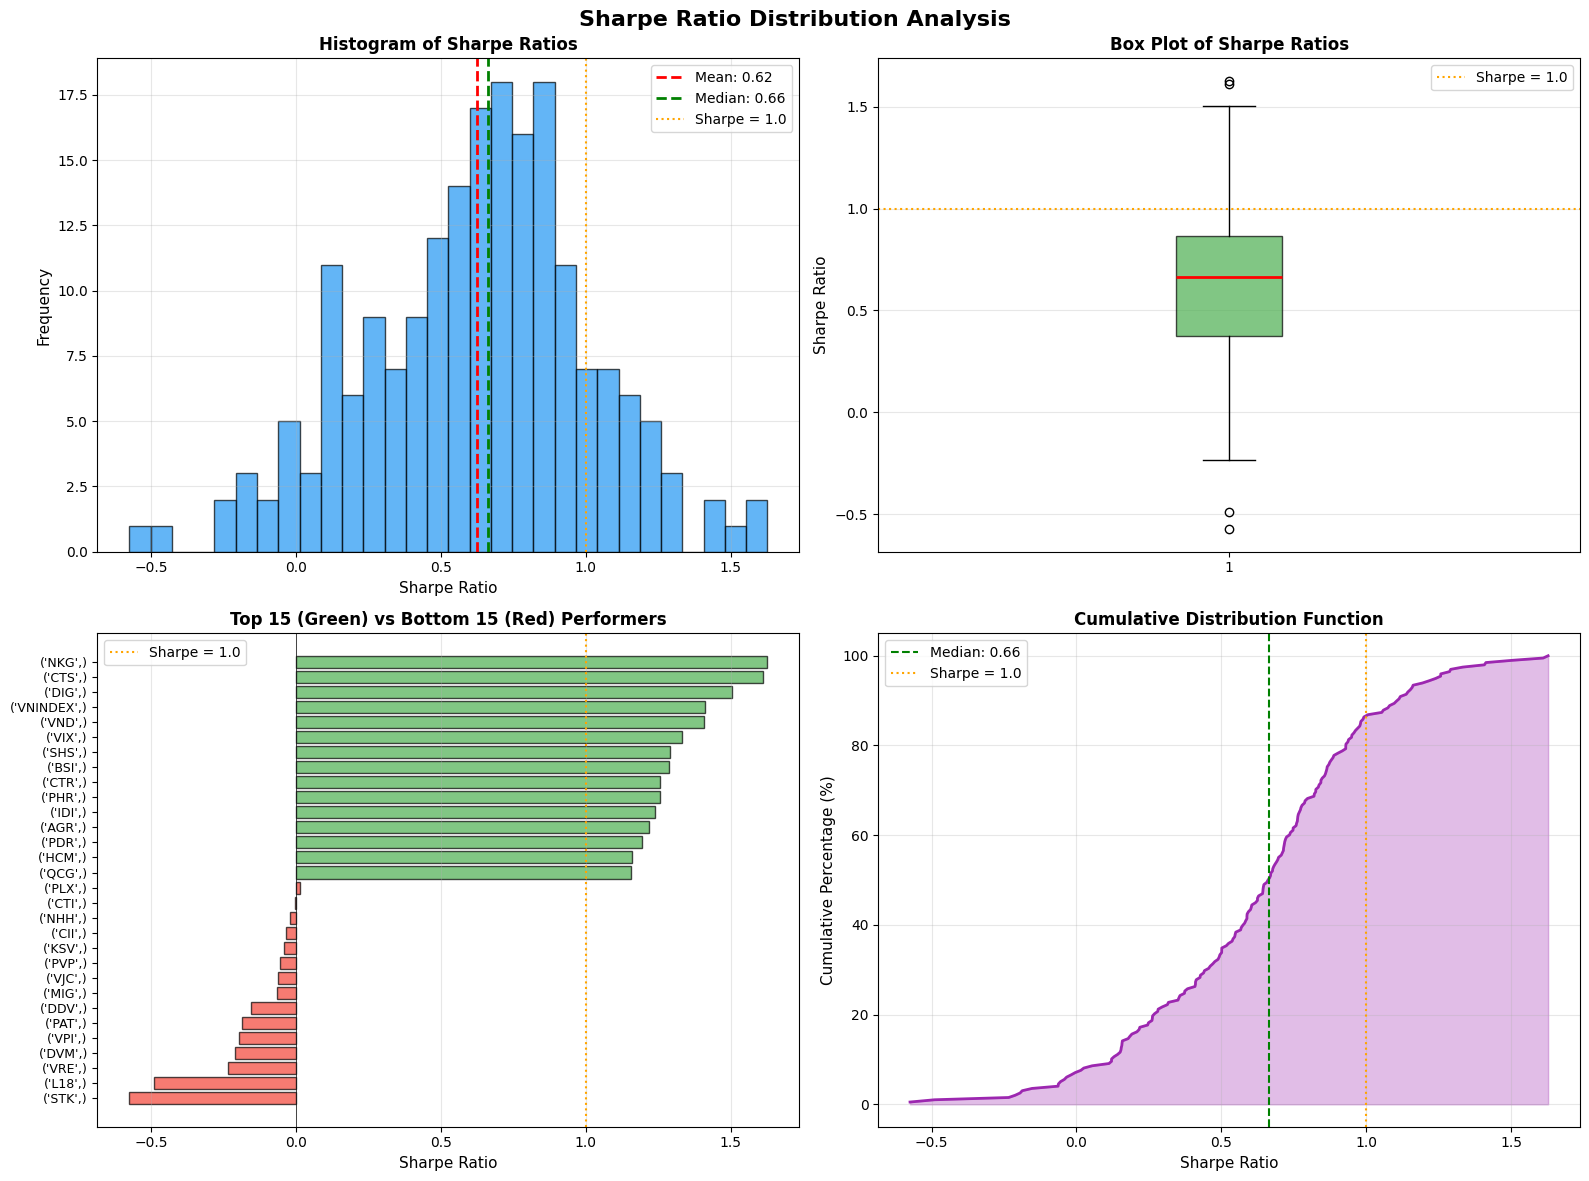


TOP 10 PERFORMERS (Highest Sharpe Ratio)
  ('PHR',):   1.256
  ('CTR',):   1.257
  ('BSI',):   1.287
  ('SHS',):   1.291
  ('VIX',):   1.332
  ('VND',):   1.407
  ('VNINDEX',):   1.412
  ('DIG',):   1.505
  ('CTS',):   1.610
  ('NKG',):   1.627

BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)
  ('STK',):  -0.574
  ('L18',):  -0.490
  ('VRE',):  -0.234
  ('DVM',):  -0.211
  ('VPI',):  -0.194
  ('PAT',):  -0.187
  ('DDV',):  -0.153
  ('MIG',):  -0.064
  ('VJC',):  -0.062
  ('PVP',):  -0.055


In [9]:
# Extract and plot Sharpe ratio distribution for each symbol
import matplotlib.pyplot as plt
import seaborn as sns

pf_best = strategy_breakout_ttm(close, high, low, best_params)
# Get stats grouped by symbol
sharpe_ratios = pf_best.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=True)
print(f"Sharpe Ratio Statistics:")
print(f"  Mean: {sharpe_ratios.mean():.3f}")
print(f"  Median: {sharpe_ratios.median():.3f}")
print(f"  Std: {sharpe_ratios.std():.3f}")
print(f"  Min: {sharpe_ratios.min():.3f}")
print(f"  Max: {sharpe_ratios.max():.3f}")
print(f"\nSymbols with Sharpe > 0.5: {(sharpe_ratios > 0.5).sum()}")
print(f"Symbols with Sharpe > 1.0: {(sharpe_ratios > 1.0).sum()}")

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sharpe Ratio Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Histogram
ax1 = axes[0, 0]
ax1.hist(sharpe_ratios.values, bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
ax1.axvline(sharpe_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sharpe_ratios.mean():.2f}')
ax1.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {sharpe_ratios.median():.2f}')
ax1.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax1.set_xlabel('Sharpe Ratio', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram of Sharpe Ratios', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot
ax2 = axes[0, 1]
bp = ax2.boxplot(sharpe_ratios.values, vert=True, patch_artist=True, 
                 boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax2.set_ylabel('Sharpe Ratio', fontsize=11)
ax2.set_title('Box Plot of Sharpe Ratios', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top/Bottom performers bar chart
ax3 = axes[1, 0]
top_n = 15
top_symbols = sharpe_ratios.tail(top_n)
bottom_symbols = sharpe_ratios.head(top_n)
combined = pd.concat([bottom_symbols, top_symbols])
colors = ['#F44336'] * len(bottom_symbols) + ['#4CAF50'] * len(top_symbols)
ax3.barh(range(len(combined)), combined.values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels(combined.index, fontsize=9)
ax3.axvline(0, color='black', linewidth=0.5)
ax3.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Top {top_n} (Green) vs Bottom {top_n} (Red) Performers', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4. Cumulative distribution
ax4 = axes[1, 1]
sorted_sharpe = np.sort(sharpe_ratios.values)
cumulative_pct = np.arange(1, len(sorted_sharpe) + 1) / len(sorted_sharpe) * 100
ax4.plot(sorted_sharpe, cumulative_pct, linewidth=2, color='#9C27B0')
ax4.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {sharpe_ratios.median():.2f}')
ax4.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax4.fill_between(sorted_sharpe, cumulative_pct, alpha=0.3, color='#9C27B0')
ax4.set_xlabel('Sharpe Ratio', fontsize=11)
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax4.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print top and bottom performers
print("\n" + "="*70)
print("TOP 10 PERFORMERS (Highest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.tail(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

print("\n" + "="*70)
print("BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.head(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

In [129]:
trials_df = study.trials_dataframe()

# Keep only successful trials
trials_df = trials_df[trials_df['state'] == 'COMPLETE'].copy()

# Bin bb_period into segments
bins = [10, 15, 20, 25]   # [10-15], (15-25]
labels = ['10-15', '15-20', '20-25']
trials_df['bb_segment'] = pd.cut(trials_df['params_bb_period'], bins=bins, labels=labels, include_lowest=True)

# Single-objective studies use 'value'; multi-objective use 'values_0'
score_col = 'value' if 'value' in trials_df.columns else 'values_0'

# Pick best trial per segment (maximize score)
best_by_segment = (
    trials_df.sort_values(score_col, ascending=False)
             .groupby('bb_segment', as_index=False)
             .first()
)

cols = [
    'bb_segment',
    score_col,
    'params_bb_period',
    'params_bb_multiplier',
    'params_kc_period',
    'params_kc_atr_period',
    'params_kc_multiplier',
    'params_donichan_period',
    'params_osc_smoothing_period',
    'params_matype',
]

best_by_segment[cols]


,bb_segment,value,params_bb_period,params_bb_multiplier,params_kc_period,params_kc_atr_period,params_kc_multiplier,params_donichan_period,params_osc_smoothing_period,params_matype
0,10-15,0.601601,10,1.2,13,10,1.0,10,5,3
1,15-20,0.488768,16,1.1,15,10,1.1,18,8,3
2,20-25,0.389545,21,1.5,19,13,1.6,23,5,2


In [121]:
# Plot optimization history
fig1 = plot_optimization_history(study)
fig1.show()

# Plot parameter importances
fig2 = plot_param_importances(study)
fig2.show()


In [ ]:
# Extract and plot Sharpe ratio distribution for each symbol
import matplotlib.pyplot as plt
import seaborn as sns

# Get stats grouped by symbol
sharpe_ratios = sharpe_best
print(f"Sharpe Ratio Statistics:")
print(f"  Mean: {sharpe_ratios.mean():.3f}")
print(f"  Median: {sharpe_ratios.median():.3f}")
print(f"  Std: {sharpe_ratios.std():.3f}")
print(f"  Min: {sharpe_ratios.min():.3f}")
print(f"  Max: {sharpe_ratios.max():.3f}")
print(f"\nSymbols with Sharpe > 1.0: {(sharpe_ratios > 1.0).sum()}")
print(f"Symbols with Sharpe > 2.0: {(sharpe_ratios > 2.0).sum()}")

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sharpe Ratio Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Histogram
ax1 = axes[0, 0]
ax1.hist(sharpe_ratios.values, bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
ax1.axvline(sharpe_ratios.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {sharpe_ratios.mean():.2f}')
ax1.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {sharpe_ratios.median():.2f}')
ax1.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax1.set_xlabel('Sharpe Ratio', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Histogram of Sharpe Ratios', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box Plot
ax2 = axes[0, 1]
bp = ax2.boxplot(sharpe_ratios.values, vert=True, patch_artist=True, 
                 boxprops=dict(facecolor='#4CAF50', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax2.set_ylabel('Sharpe Ratio', fontsize=11)
ax2.set_title('Box Plot of Sharpe Ratios', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top/Bottom performers bar chart
ax3 = axes[1, 0]
top_n = 15
top_symbols = sharpe_ratios.tail(top_n)
bottom_symbols = sharpe_ratios.head(top_n)
combined = pd.concat([bottom_symbols, top_symbols])
colors = ['#F44336'] * len(bottom_symbols) + ['#4CAF50'] * len(top_symbols)
ax3.barh(range(len(combined)), combined.values, color=colors, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(combined)))
ax3.set_yticklabels(combined.index, fontsize=9)
ax3.axvline(0, color='black', linewidth=0.5)
ax3.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Top {top_n} (Green) vs Bottom {top_n} (Red) Performers', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

# 4. Cumulative distribution
ax4 = axes[1, 1]
sorted_sharpe = np.sort(sharpe_ratios.values)
cumulative_pct = np.arange(1, len(sorted_sharpe) + 1) / len(sorted_sharpe) * 100
ax4.plot(sorted_sharpe, cumulative_pct, linewidth=2, color='#9C27B0')
ax4.axvline(sharpe_ratios.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {sharpe_ratios.median():.2f}')
ax4.axvline(1.0, color='orange', linestyle=':', linewidth=1.5, label='Sharpe = 1.0')
ax4.fill_between(sorted_sharpe, cumulative_pct, alpha=0.3, color='#9C27B0')
ax4.set_xlabel('Sharpe Ratio', fontsize=11)
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax4.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print top and bottom performers
print("\n" + "="*70)
print("TOP 10 PERFORMERS (Highest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.tail(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

print("\n" + "="*70)
print("BOTTOM 10 PERFORMERS (Lowest Sharpe Ratio)")
print("="*70)
for symbol, sharpe in sharpe_ratios.head(10).items():
    print(f"  {symbol}: {sharpe:7.3f}")

In [112]:
symbol = 'KDH'
# df1 = pd.DataFrame(pf[symbol].trades.records_readable)
# df1

df2 = pd.DataFrame(pf[symbol].stats())
df2

,KDH
Start,2016-01-29 00:00:00
End,2026-01-27 00:00:00
Period,2498 days 00:00:00
Start Value,100.0
End Value,667.686232
Total Return [%],567.686232
Benchmark Return [%],345.0
Max Gross Exposure [%],100.0
Total Fees Paid,0.0
Max Drawdown [%],35.140046


In [109]:
symbol = 'KDH'
df1 = pd.DataFrame(pf[symbol].trades.records_readable)
df1

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,"(20, 20, 1.9, 10, KDH)",14.104372,2016-08-10,7.09,0.0,2016-10-19,7.95,0.0,12.129760,0.121298,Long,Closed,0
1,1,"(20, 20, 1.9, 10, KDH)",14.695906,2016-11-10,7.63,0.0,2017-04-07,9.42,0.0,26.305671,0.234600,Long,Closed,1
2,2,"(20, 20, 1.9, 10, KDH)",13.121842,2017-05-09,10.55,0.0,2017-05-19,10.17,0.0,-4.986300,-0.036019,Long,Closed,2
3,3,"(20, 20, 1.9, 10, KDH)",11.936416,2017-07-13,11.18,0.0,2017-07-17,10.83,0.0,-4.177746,-0.031306,Long,Closed,3
4,4,"(20, 20, 1.9, 10, KDH)",12.014069,2017-07-19,10.76,0.0,2017-09-11,10.57,0.0,-2.282673,-0.017658,Long,Closed,4
5,5,"(20, 20, 1.9, 10, KDH)",11.178584,2017-10-04,11.36,0.0,2017-10-18,11.36,0.0,0.000000,0.000000,Long,Closed,5
6,6,"(20, 20, 1.9, 10, KDH)",10.486269,2017-11-15,12.11,0.0,2017-11-23,13.13,0.0,10.695994,0.084228,Long,Closed,6
7,7,"(20, 20, 1.9, 10, KDH)",10.526354,2018-01-11,13.08,0.0,2018-02-05,14.71,0.0,17.157957,0.124618,Long,Closed,7
8,8,"(20, 20, 1.9, 10, KDH)",9.135260,2018-03-05,16.95,0.0,2018-03-09,15.75,0.0,-10.962312,-0.070796,Long,Closed,8
9,9,"(20, 20, 1.9, 10, KDH)",7.984481,2018-04-09,18.02,0.0,2018-04-23,17.27,0.0,-5.988361,-0.041620,Long,Closed,9


In [108]:
ttms.xs('KDH', axis=1, level='symbol').tail(20)

linearreg_timeperiod,20
max_timeperiod,20
date,
2025-12-29,-0.750768
2025-12-30,-0.695839
2025-12-31,-0.558018
2026-01-05,-0.279304
2026-01-06,-0.018429
2026-01-07,0.104304
2026-01-08,0.058893
2026-01-09,-0.335554
